In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("cancerdata.csv")

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df["diagnosis"] = (df["diagnosis"] == "M").astype(int)

In [17]:
df = df.drop(columns = "Unnamed: 32")

In [18]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

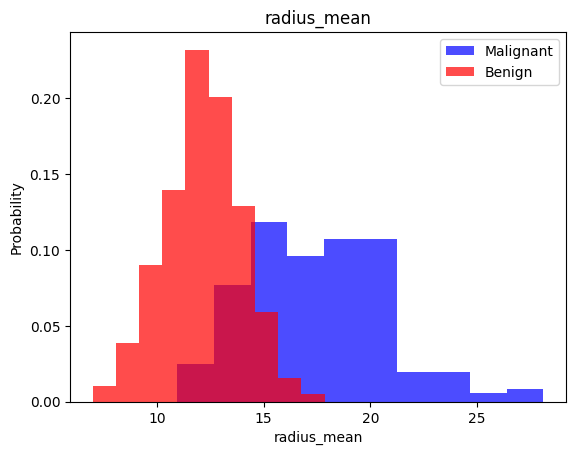

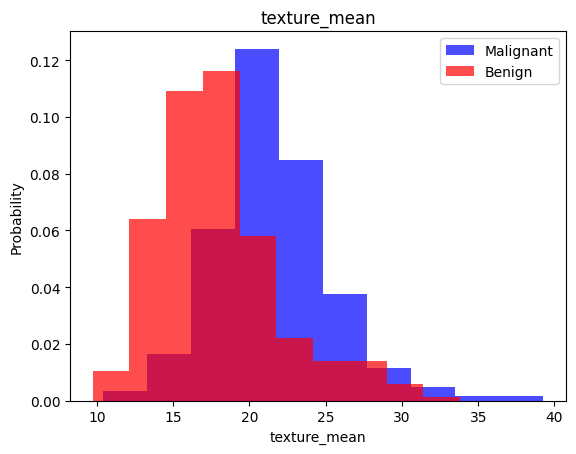

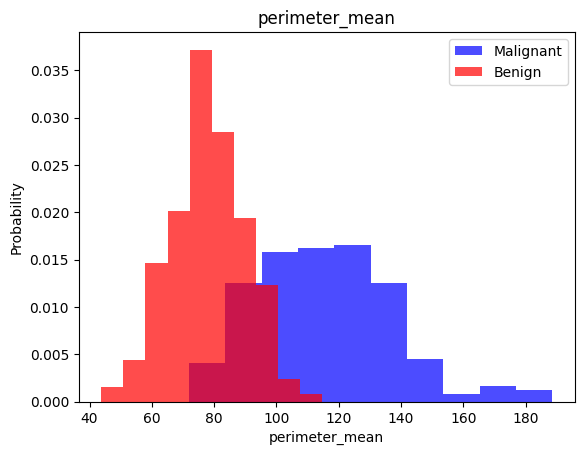

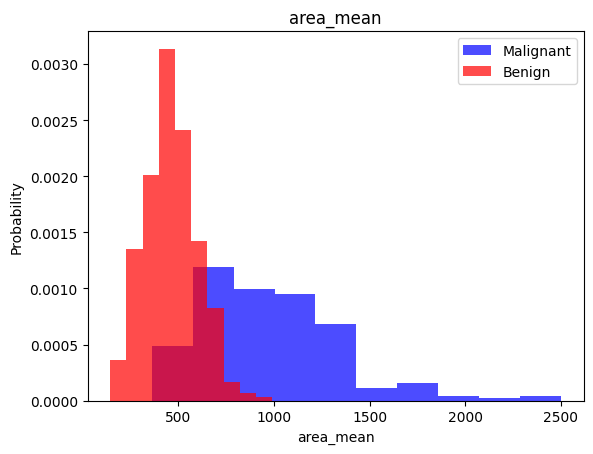

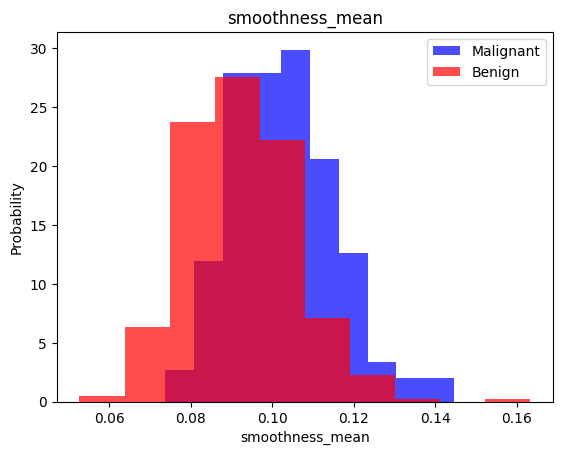

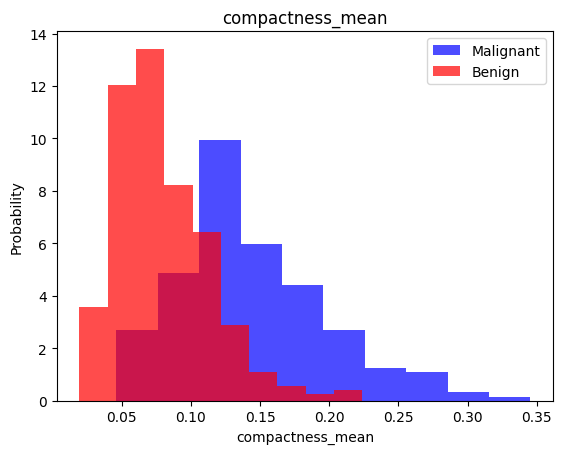

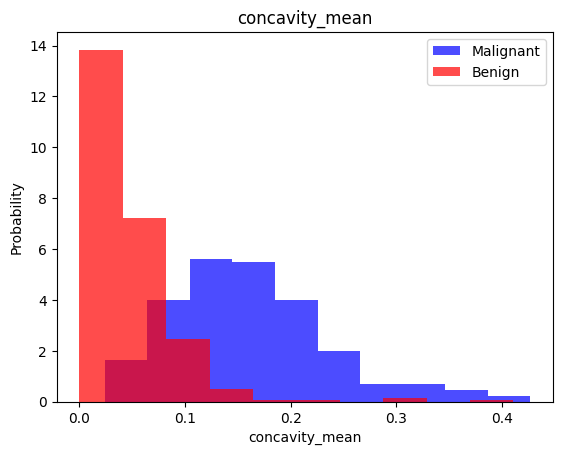

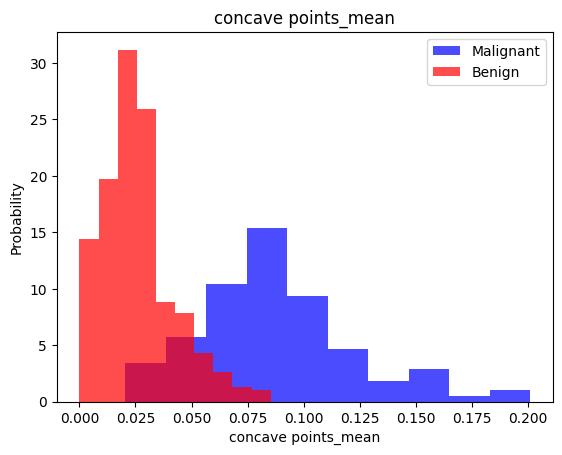

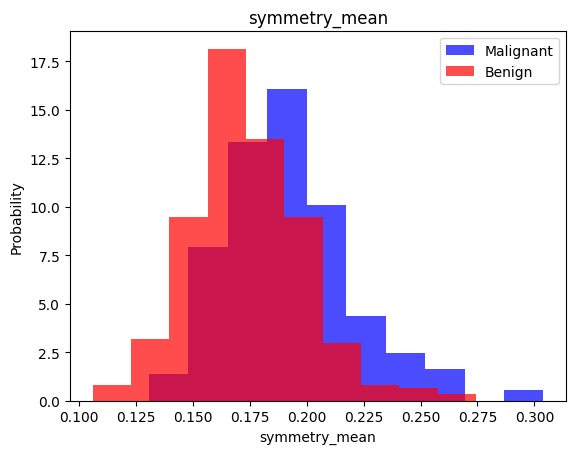

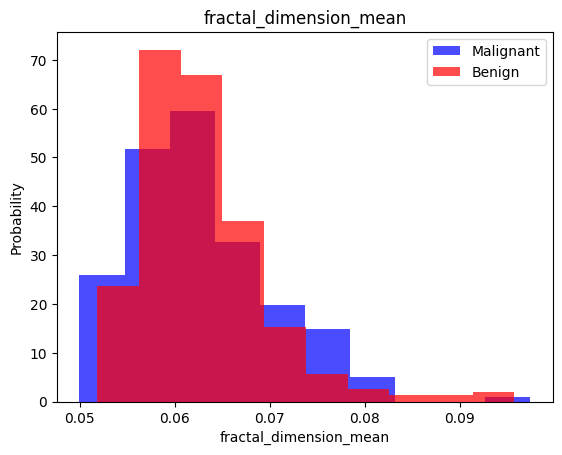

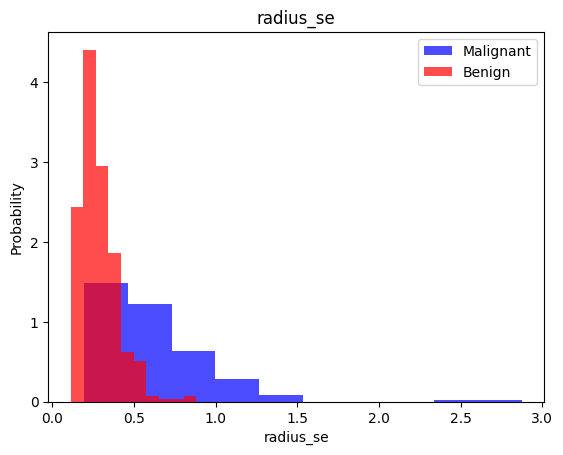

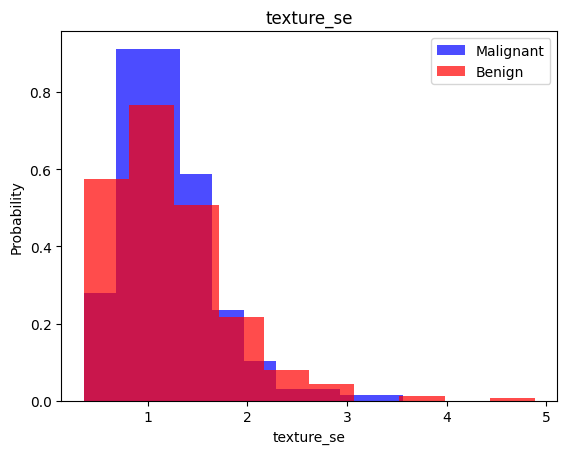

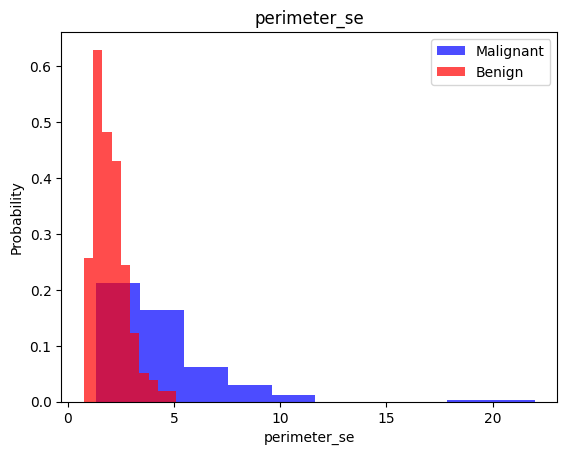

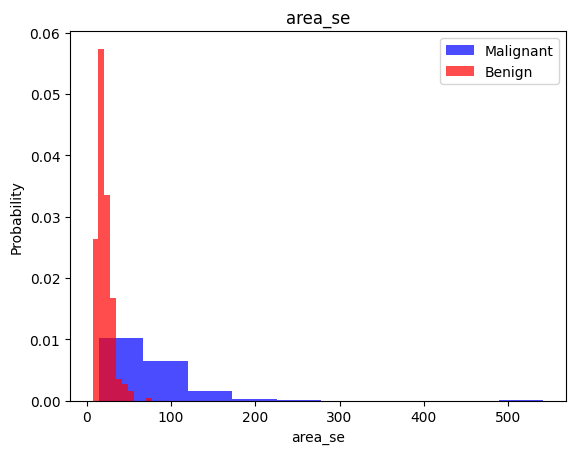

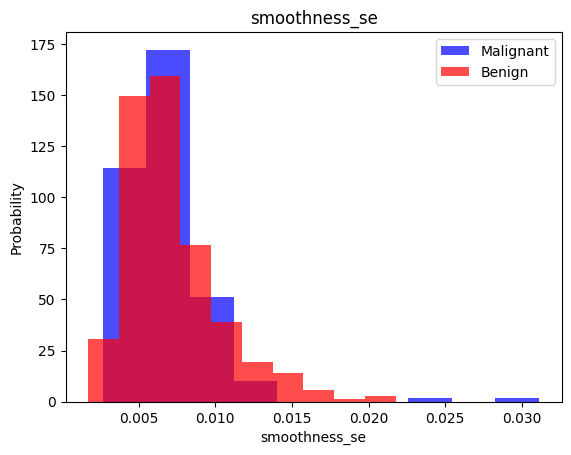

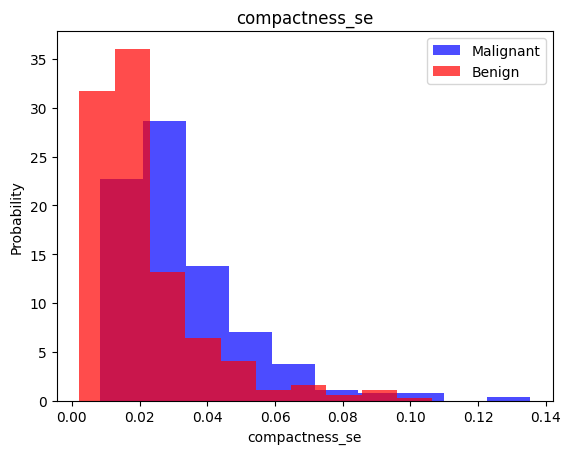

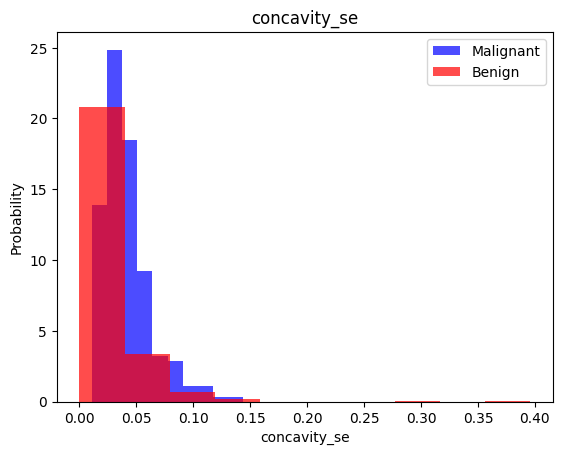

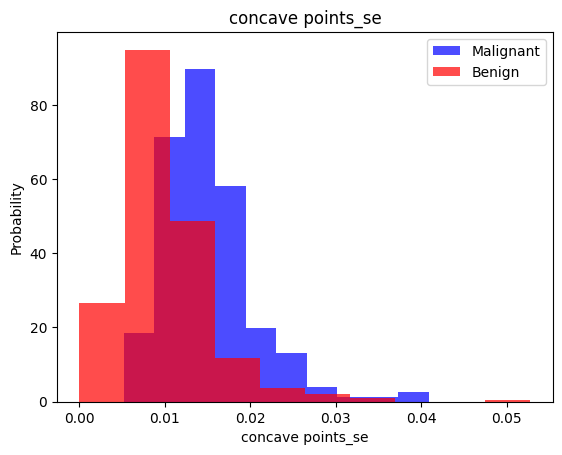

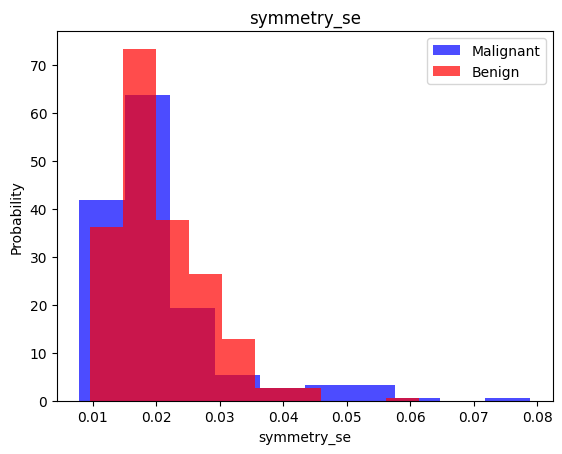

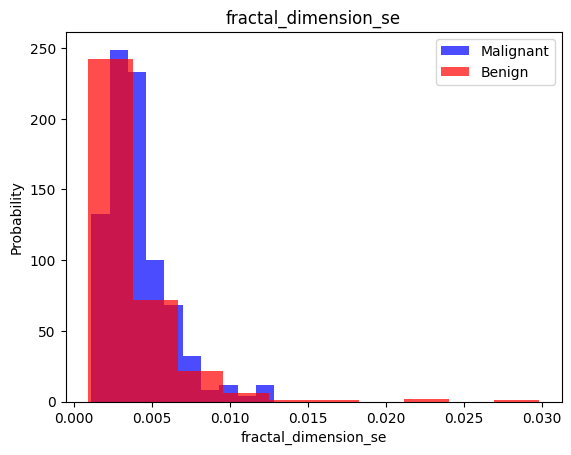

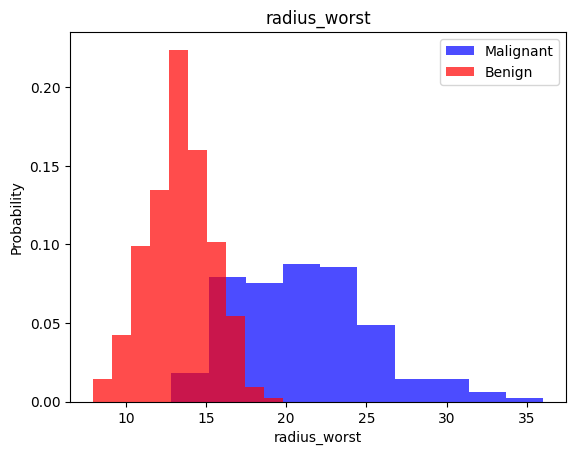

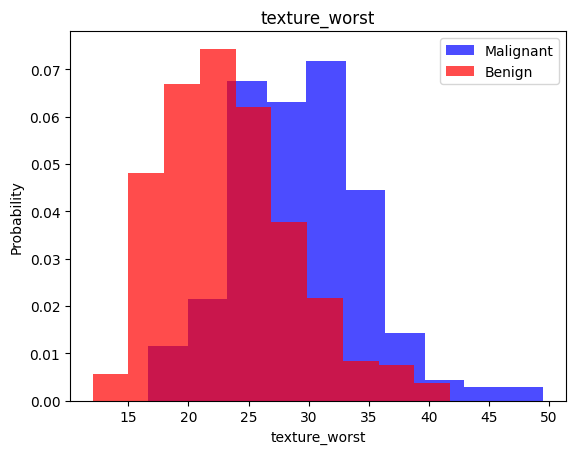

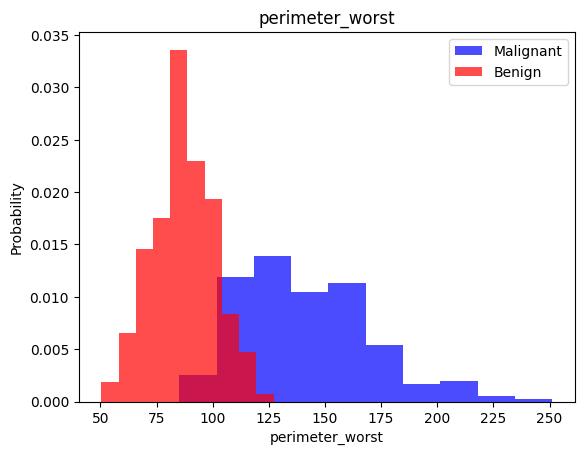

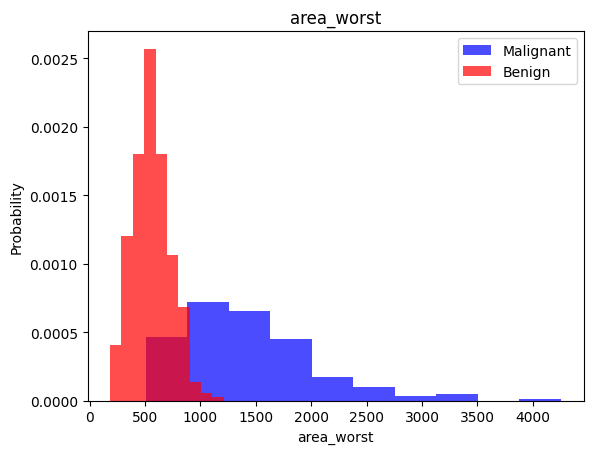

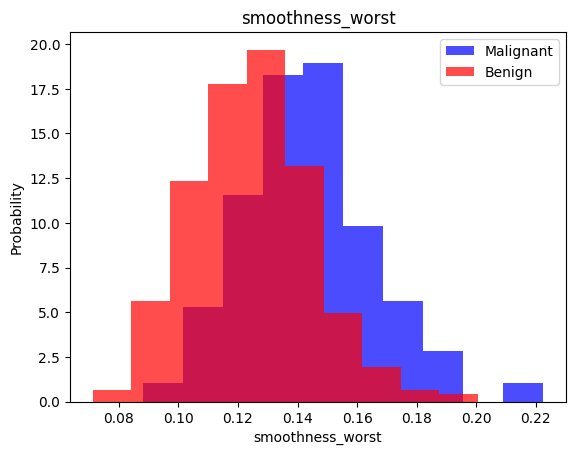

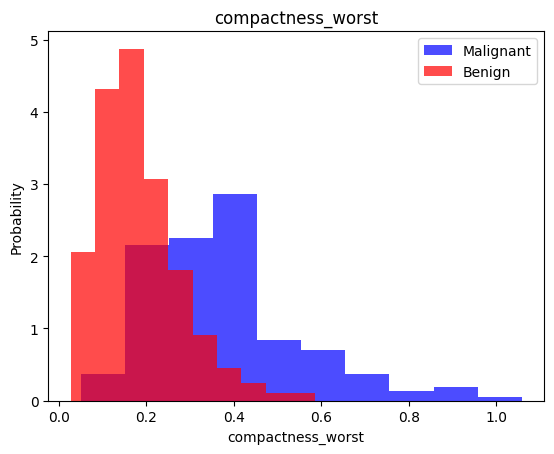

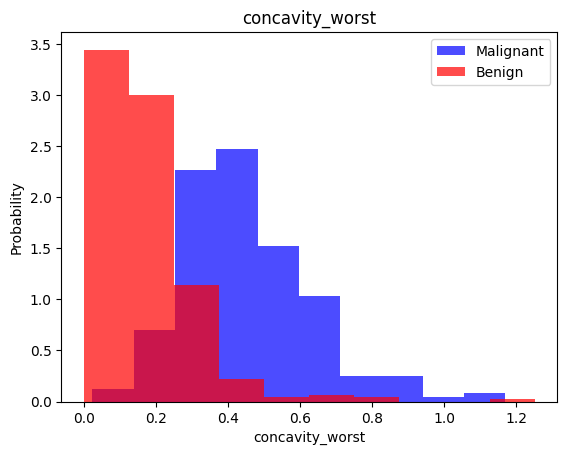

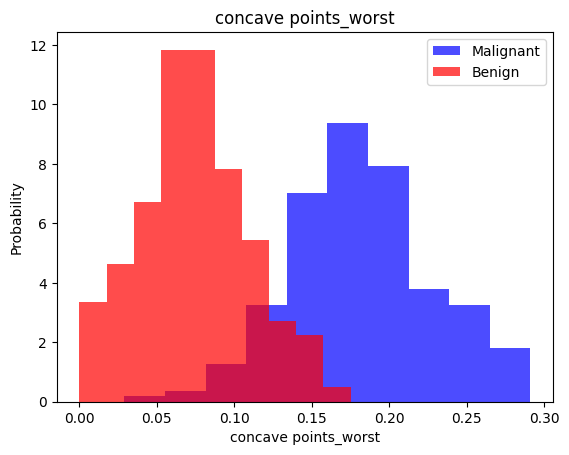

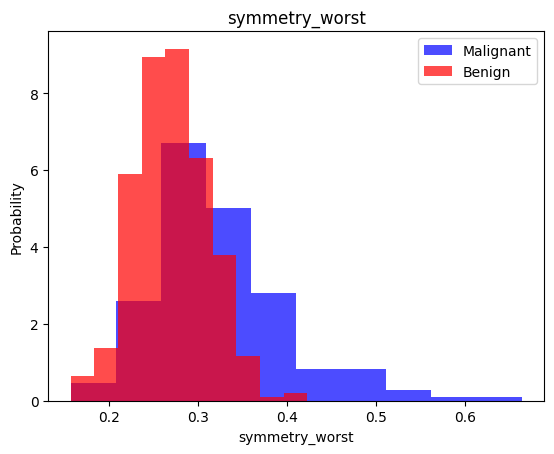

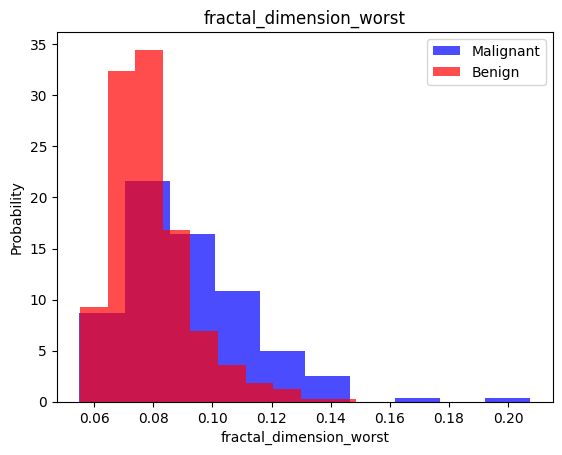

In [19]:
for cols in df.columns[2:]:
    plt.hist(df[df["diagnosis"] == 1][cols], color = "blue", label = "Malignant", alpha = 0.7, density = True)
    plt.hist(df[df["diagnosis"] == 0][cols], color = "red", label = "Benign", alpha = 0.7, density = True)
    plt.title(cols)
    plt.ylabel("Probability")
    plt.xlabel(cols)
    plt.legend()
    plt.show()

## Creating our Training, Validation, Testing Datasets

In [20]:
train, valid, test = np.split(df.sample(frac = 1), [int(0.6*len(df)), int(0.8*len(df))])

C:\Program Files\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [31]:
def scale_dataset(dataframe, oversample = False):
    x = dataframe[dataframe.columns[2:]].values
    y = dataframe[dataframe.columns[1]].values

    scaler = StandardScaler()
    x = scaler.fit_transform(x)

    if oversample:
        ros = RandomOverSampler()
        x, y = ros.fit_resample(x, y)
    
    data = np.hstack((x, np.reshape(y, (len(y), 1))))

    return data, x, y

In [32]:
print(len(train[train["diagnosis"] == 1])) #Malignant
print(len(train[train["diagnosis"] == 0])) #Benign

124
217


In [33]:
train, x_train, y_train = scale_dataset(train, oversample = True)

In [34]:
print(sum(y_train == 1))
print(sum(y_train == 0))

217
217


In [35]:
valid, x_valid, y_valid = scale_dataset(valid, oversample = False)
test, x_test, y_test = scale_dataset(test, oversample = False)

## K-Nearest Neighbors

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [37]:
knn_model = KNeighborsClassifier(n_neighbors = 3)
knn_model.fit(x_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
y_pred = knn_model.predict(x_test)

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        63
           1       1.00      0.92      0.96        51

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [43]:
print(y_pred)
print(y_test)

[0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 1 0
 1 1 0 1 0 0 1 0 1 0 1 1 1 1 0 1 0 1 0 0 0 1 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1
 1 1 1 0 0 1 0 1 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1
 1 1 0]
[0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 1 1 1 0 0 0 1 1
 1 1 1 1 0 1 1 0 1 0 1 1 1 1 0 1 0 1 0 0 0 1 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1
 1 1 1 0 0 1 0 1 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1
 1 1 0]
